In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv("salary_data_cleanedv2.csv")
df.head()

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Company Age,Python,R,AWS,Spark,Excel,Job Simplified,Seniority,Desc Length,Competitor Count
0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,...,53,1,0,0,0,1,data scientist,na,2536,0
1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,...,42,1,0,0,0,0,data scientist,na,4783,0
2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,...,16,1,0,0,1,1,data scientist,na,3461,0
3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,...,61,1,0,0,0,0,data scientist,na,3883,3
4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,...,28,1,0,0,0,1,data scientist,na,2728,3


In [5]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Hourly', 'Employer Provided', 'Min Salary', 'Max Salary', 'Avg Salary',
       'State', 'Same State', 'Company Age', 'Python', 'R', 'AWS', 'Spark',
       'Excel', 'Job Simplified', 'Seniority', 'Desc Length',
       'Competitor Count'],
      dtype='object')

Choose columns that seem relevant

In [6]:
df_model = df[['Rating','State','Same State','Size','Type of ownership','Industry','Sector','Revenue',
               'Competitor Count','Hourly','Employer Provided','Min Salary','Max Salary','Avg Salary',
               'Company Age','Python','R','AWS','Spark','Excel','Job Simplified','Seniority','Desc Length']]
df_model.head()

,Rating,State,Same State,Size,Type of ownership,Industry,Sector,Revenue,Competitor Count,Hourly,...,Avg Salary,Company Age,Python,R,AWS,Spark,Excel,Job Simplified,Seniority,Desc Length
0,3.8,NM,0,501 to 1000 employees,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),0,0,...,72.0,53,1,0,0,0,1,data scientist,na,2536
1,3.4,MD,0,10000+ employees,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),0,0,...,87.5,42,1,0,0,0,0,data scientist,na,4783
2,4.8,FL,1,501 to 1000 employees,Company - Private,Security Services,Business Services,$100 to $500 million (USD),0,0,...,85.0,16,1,0,0,1,1,data scientist,na,3461
3,3.8,WA,1,1001 to 5000 employees,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),3,0,...,76.5,61,1,0,0,0,0,data scientist,na,3883
4,2.9,NY,1,51 to 200 employees,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,0,...,114.5,28,1,0,0,0,1,data scientist,na,2728


Now we get dummy data

In [7]:
df_dum = pd.get_dummies(df_model)

Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = df_dum.drop('Avg Salary', axis=1)
y = df_dum['Avg Salary'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Multiple Linear Regression

In [7]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
from sklearn.model_selection import cross_val_score
cross_val_score(lm, X_train, y_train, scoring='neg_mean_absolute_error')

array([-0.49472537, -0.4045292 , -0.43328404, -0.52083476, -0.4139357 ])

Lasso Regression

In [9]:
from sklearn.linear_model import Lasso

lm_l = Lasso()
lm_l.fit(X_train, y_train)
cross_val_score(lm_l, X_train, y_train, scoring='neg_mean_absolute_error')

array([-1.61927071, -2.07876984, -2.33303898, -2.37065896, -2.08190482])

Now, we change alpha to see which alpha values performs best (default was 1)

c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\base.py:1365: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.407e+02, tolerance: 7.242e+01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
c:\

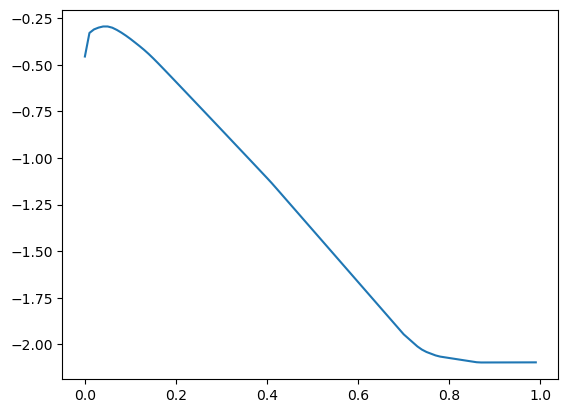

In [10]:
alpha = []
error = []
for i in range(0,100):
    alpha.append(i/100)
    lml = Lasso(alpha=(i/100))
    error.append(np.mean(cross_val_score(lml, X_train, y_train, scoring='neg_mean_absolute_error')))

plt.plot(alpha, error)
plt.show()

Peaks around alpha=0.1

In [11]:
lm_l = Lasso(alpha=0.1)
lm_l.fit(X_train, y_train)
cross_val_score(lm_l, X_train, y_train, scoring='neg_mean_absolute_error')

array([-0.20644701, -0.38135149, -0.43383425, -0.49955735, -0.28705061])

Now we try Random Forest

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
cross_val_score(rf, X_train, y_train, scoring='neg_mean_absolute_error')

array([-1.02869748, -0.92773109, -1.00289916, -1.56148305, -0.74271186])

Now, we have GridSearchCV give us the best model

In [13]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_estimators':range(10,300,10),'criterion': ('squared_error','absolute_error'), 'max_features':('auto','sqrt','log2')}

gs = GridSearchCV(rf, parameters, scoring ='neg_mean_absolute_error')

In [14]:
gs.fit(X_train, y_train)

c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
290 fits failed out of a total of 870.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
290 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\base.py", line 471, in _validate_params
    v

,estimator,RandomForestRegressor()
,param_grid,"{'criterion': ('squared_error', ...), 'max_features': ('auto', ...), 'n_estimators': range(10, 300, 10)}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,90


so n_estimators = 140, criterion = 'abolute_error' and max_features = 'sqrt' gave the best results

Now , we perform prediction

In [15]:
tpred_lm = lm.predict(X_test)
tpred_lml = lm_l.predict(X_test)
tpred_rf = gs.best_estimator_.predict(X_test)

In [16]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, tpred_lm)

0.42252433907082493

In [17]:
mean_absolute_error(y_test, tpred_lml)

0.2535006189317818

In [18]:
mean_absolute_error(y_test, tpred_rf)

4.806357196122296

So, Lasso performed the best on the dataset

Now, we deploy the model and expose it via Flask API Endpoint

In [21]:
import pickle
pickl = {'model': lm_l}
pickle.dump(pickl, open('model_file'+'.p','wb'))

file_name = "model_file.p"
with open(file_name, 'rb') as pickled:
    data = pickle.load(pickled)
    model = data['model']

In [22]:
model.predict(X_test.iloc[1,:].values.reshape(1,-1))

c:\Users\Aadi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(


array([48.31772425])

In [13]:
X_test.iloc[1,:]

Rating                  3.6
Same State                1
Competitor Count          0
Hourly                    0
Employer Provided         0
                      ...  
Job Simplified_mle    False
Job Simplified_na     False
Seniority_jr          False
Seniority_na           True
Seniority_senior      False
Name: 196, Length: 181, dtype: object